In [1]:
!pip install openai pandas scikit-learn -q

In [2]:
import os
import pandas as pd
from openai import OpenAI

In [3]:
try:
    from google.colab import userdata
    OPENROUTER_API_KEY = userdata.get('OPENROUTER_API')
except Exception:
    OPENROUTER_API_KEY = os.getenv('OPENROUTER_API')

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

MODEL = "arcee-ai/trinity-large-preview:free"



In [4]:
df = pd.read_csv("Telco_Customer_Churn.csv")
df.head(20)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [5]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [7]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

le = LabelEncoder()

for col in df_ml.columns:
    if df_ml[col].dtype == "object":
        df_ml[col] = le.fit_transform(df_ml[col])

In [8]:
from sklearn.model_selection import train_test_split

X = df_ml.drop("Churn",axis=1)
y = df_ml["Churn"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [9]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=10000,class_weight='balanced')
lr_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=10000)

In [10]:
from sklearn.metrics import accuracy_score

y_pred = lr_model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.7572746628814763


In [11]:
from sklearn.metrics import precision_score, recall_score, classification_report, confusion_matrix

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("\nConfusion Matrix Values:")
print("TP:", tp, "FP:", fp, "FN:", fn, "TN:", tn)




Precision: 0.5258764607679466
Recall: 0.8445040214477212

Confusion Matrix Values:
TP: 315 FP: 284 FN: 58 TN: 752


In [12]:
y_prob = lr_model.predict_proba(X_test)[:,1]

results = X_test.copy()
results["Actual_Churn"] = y_test.values
results["Predicted_Score"] = y_prob

def risk_category(score):
    if score > 0.65:
        return "H"
    elif score > 0.35:
        return "M"
    else:
        return "L"

results["Risk"] = results["Predicted_Score"].apply(risk_category)

results.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Predicted_Score,Risk
185,692,0,0,1,0,1,0,1,0,0,...,0,0,0,1,2,24.80,24.80,1,0.830237,H
2715,325,1,0,0,0,41,1,2,2,1,...,1,1,0,1,0,25.25,996.45,0,0.168666,L
3825,2527,0,0,1,1,52,1,0,2,1,...,1,1,2,0,3,19.35,1031.70,0,0.014437,L
1807,4911,0,0,0,0,1,1,0,1,0,...,0,0,0,0,2,76.35,76.35,1,0.775224,H
132,6058,1,0,0,0,67,1,0,0,0,...,0,0,2,0,0,50.55,3260.10,0,0.017264,L


In [13]:

high_risk_customers = results[results["Risk"]=="H"]

top5_high_risk = high_risk_customers.sort_values(
    by="Predicted_Score",
    ascending=False
).head(5)

print("Top 5 High Risk Customers:")
top5_high_risk

Top 5 High Risk Customers:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Predicted_Score,Risk
2208,5126,0,1,1,0,1,1,2,1,0,...,2,2,0,1,2,100.80,100.80,1,0.924693,H
1410,4997,0,1,0,0,2,1,2,1,0,...,2,2,0,1,2,93.85,170.85,1,0.921464,H
4800,6549,1,1,0,0,1,1,2,1,0,...,2,2,0,1,2,94.00,94.00,1,0.918632,H
2191,2804,0,1,0,0,1,1,0,1,0,...,2,2,0,1,2,91.30,91.30,1,0.915277,H
2577,3465,0,0,0,0,1,1,2,1,0,...,2,2,0,1,2,94.60,94.60,1,0.914799,H


In [14]:
high_risk = results[results["Risk"] == "H"].sort_values(
    by="Predicted_Score", ascending=False
).head(3)

medium_risk = results[results["Risk"] == "M"].sort_values(
    by="Predicted_Score", ascending=False
).head(3)

low_risk = results[results["Risk"] == "L"].sort_values(
    by="Predicted_Score", ascending=False
).head(3)

print("High Risk Customers:")
print(high_risk)

print("\nMedium Risk Customers:")
print(medium_risk)

print("\nLow Risk Customers:")
print(low_risk)

High Risk Customers:
      customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
2208        5126       0              1        1           0       1   
1410        4997       0              1        0           0       2   
4800        6549       1              1        0           0       1   

      PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  \
2208             1              2                1               0  ...   
1410             1              2                1               0  ...   
4800             1              2                1               0  ...   

      StreamingTV  StreamingMovies  Contract  PaperlessBilling  PaymentMethod  \
2208            2                2         0                 1              2   
1410            2                2         0                 1              2   
4800            2                2         0                 1              2   

      MonthlyCharges  TotalCharges  Actual_Churn  Predicted_Scor

In [15]:
importance_lr = pd.Series(
    abs(lr_model.coef_[0]),
    index=X.columns
).sort_values(ascending=False)

print(importance_lr.head(10))
print("Top 5 High Risk Customers:")
print(top5_high_risk)

PhoneService        0.986915
Contract            0.768396
PaperlessBilling    0.340953
OnlineSecurity      0.284784
TechSupport         0.244312
InternetService     0.207423
SeniorCitizen       0.171665
Dependents          0.170911
OnlineBackup        0.150191
DeviceProtection    0.091797
dtype: float64
Top 5 High Risk Customers:
      customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
2208        5126       0              1        1           0       1   
1410        4997       0              1        0           0       2   
4800        6549       1              1        0           0       1   
2191        2804       0              1        0           0       1   
2577        3465       0              0        0           0       1   

      PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  \
2208             1              2                1               0  ...   
1410             1              2                1               0  ...   
4800      

In [16]:


top3_drivers = importance_lr.head(3)

print("Top 3 drivers pushing customers into high risk:")
print(top3_drivers)

Top 3 drivers pushing customers into high risk:
PhoneService        0.986915
Contract            0.768396
PaperlessBilling    0.340953
dtype: float64


In [17]:
def build_context(df):

    total = len(df)

    churn_rate = df["Churn"].mean()*100

    ctx = f"""Telco Churn Dataset — {total} customers, {len(df.columns)} columns
Columns: {', '.join(df.columns)}

Churn rate: {churn_rate:.1f}%

Model accuracy: {accuracy:.2f}

Top churn drivers:
{importance_lr.head(5).to_string()}

Churn by Contract:
{df.groupby('Contract')['Churn'].mean().mul(100).round(1).astype(str)+'%'}

Avg Monthly Charges:
Churned: ${df[df['Churn']==1]['MonthlyCharges'].mean():.2f}
Retained: ${df[df['Churn']==0]['MonthlyCharges'].mean():.2f}

Avg Tenure:
Churned: {df[df['Churn']==1]['tenure'].mean():.1f}
Retained: {df[df['Churn']==0]['tenure'].mean():.1f}

Churn by Internet Service:
{df.groupby('InternetService')['Churn'].mean().mul(100).round(1).astype(str)+'%'}

Churn by Payment Method:
{df.groupby('PaymentMethod')['Churn'].mean().mul(100).round(1).astype(str)+'%'}
"""

    return ctx

ROC AUC Score: 0.8619277071019698


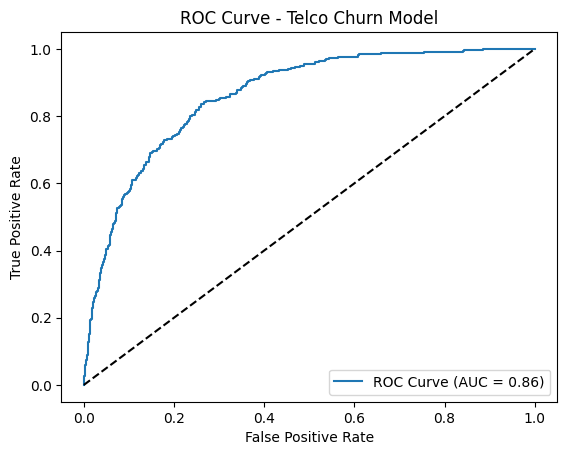

In [18]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

print("ROC AUC Score:", roc_auc)

plt.figure()

plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Telco Churn Model")
plt.legend(loc="lower right")

plt.show()

In [19]:
CONTEXT = build_context(df)

print(CONTEXT)

Telco Churn Dataset — 7043 customers, 21 columns
Columns: customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn

Churn rate: 26.5%

Model accuracy: 0.76

Top churn drivers:
PhoneService        0.986915
Contract            0.768396
PaperlessBilling    0.340953
OnlineSecurity      0.284784
TechSupport         0.244312

Churn by Contract:
Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: Churn, dtype: object

Avg Monthly Charges:
Churned: $74.44
Retained: $61.27

Avg Tenure:
Churned: 18.0
Retained: 37.6

Churn by Internet Service:
InternetService
DSL            19.0%
Fiber optic    41.9%
No              7.4%
Name: Churn, dtype: object

Churn by Payment Method:
PaymentMethod
Bank transfer (automatic)    16.7%
Credit card (automatic

In [20]:
def ask(question):

    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": "You are a data analyst. Answer using only the dataset stats provided."},
            {"role": "user",   "content": f"Dataset:\n{CONTEXT}\n\nQuestion: {question}"}
        ],
        max_tokens=300,
    )

    print(f"Q: {question}")
    print("-" * 50)
    print(response.choices[0].message.content.strip())
    print()

In [21]:
ask("Describe the dataset")




Q: Describe the dataset
--------------------------------------------------
The Telco Churn Dataset contains 7,043 customer records with 21 attributes covering demographic information (gender, senior citizen status, partner/dependent status), service usage details (phone service, internet service type, streaming services), contract terms, billing preferences, payment methods, and financial metrics (monthly charges, total charges). The dataset exhibits a churn rate of 26.5%, meaning approximately 1 in 4 customers discontinued service.

The dataset reveals several key patterns. Contract type shows strong correlation with churn - month-to-month customers churn at 42.7% compared to just 2.8% for two-year contracts. Internet service type also impacts churn significantly, with fiber optic customers churning at 41.9% versus 19.0% for DSL customers. Payment method shows electronic check users churn at the highest rate (45.3%).

Financial metrics differ notably between churned and retained custo

In [22]:
ask("What are the high-risk customer characteristics?")


Q: What are the high-risk customer characteristics?
--------------------------------------------------
Based on the dataset analysis, the high-risk customer characteristics for churn are:

1. Month-to-month contract: These customers have a 42.7% churn rate, which is significantly higher than other contract types.

2. Fiber optic internet service: Customers with fiber optic internet service have a 41.9% churn rate, the highest among all internet service types.

3. Electronic check payment method: This payment method is associated with a 45.3% churn rate, the highest among all payment methods.

4. High monthly charges: Churned customers have an average monthly charge of $74.44, compared to $61.27 for retained customers.

5. Short tenure: Churned customers have an average tenure of 18 months, while retained customers average 37.6 months.

6. No phone service: This feature has a high importance score (0.986915) in predicting churn.

7. No online security: This feature has a moderate import

In [23]:
ask("Which payment method has the highest churn?")

Q: Which payment method has the highest churn?
--------------------------------------------------
Electronic check has the highest churn rate at 45.3% among the payment methods.



In [24]:
ask("Why is customer 6058 will not churn?")

Q: Why is customer 6058 will not churn?
--------------------------------------------------
Based on the dataset statistics provided, there are several factors that suggest customer 6058 is likely to stay with the telco service:

1. Contract type: Customers with longer contracts (one year or two year) have significantly lower churn rates (11.3% and 2.8% respectively) compared to month-to-month contracts (42.7%). If customer 6058 has a longer contract, this greatly reduces their likelihood of churning.

2. Internet Service: Fiber optic customers have a high churn rate (41.9%), while DSL customers churn at a much lower rate (19.0%). If customer 6058 uses DSL, this decreases their likelihood of churning.

3. Payment Method: Customers using bank transfer or credit card (automatic) have lower churn rates (16.7% and 15.2% respectively) compared to electronic check users (45.3%). If customer 6058 uses an automatic payment method, this reduces their likelihood of churning.

4. Phone Service: On

In [25]:
# test no of cases 3 in high and medium risk 3 whether they give same reason or not

In [26]:
ask("Analyze 3 high-risk customers and identify the top 3 reasons why they are likely to churn. Explain if the reasons are similar across these customers.")

Q: Analyze 3 high-risk customers and identify the top 3 reasons why they are likely to churn. Explain if the reasons are similar across these customers.
--------------------------------------------------
Based on the provided dataset, I'll analyze three high-risk customers and identify their top churn drivers:

Customer 1:
- Contract: Month-to-month
- InternetService: Fiber optic
- PaymentMethod: Electronic check

Top 3 churn reasons:
1. Month-to-month contract (42.7% churn rate for this contract type)
2. Fiber optic internet service (41.9% churn rate)
3. Electronic check payment method (45.3% churn rate)

Customer 2:
- Contract: Month-to-month
- InternetService: Fiber optic
- PaymentMethod: Mailed check

Top 3 churn reasons:
1. Month-to-month contract (42.7% churn rate)
2. Fiber optic internet service (41.9% churn rate)
3. Mailed check payment method (19.1% churn rate)

Customer 3:
- Contract: Month-to-month
- InternetService: DSL
- PaymentMethod: Electronic check

Top 3 churn reasons

In [27]:
ask("Analyze 3 medium-risk customers and identify the top 3 factors contributing to their churn risk. Explain whether the reasons are similar or vary between customers.")

Q: Analyze 3 medium-risk customers and identify the top 3 factors contributing to their churn risk. Explain whether the reasons are similar or vary between customers.
--------------------------------------------------
Based on the dataset statistics provided, I'll analyze three medium-risk customers and identify the top 3 factors contributing to their churn risk. I'll then explain whether the reasons are similar or vary between customers.

Customer 1:
1. Contract: Month-to-month (42.7% churn rate for this contract type)
2. InternetService: Fiber optic (41.9% churn rate)
3. PaperlessBilling: Yes (34.1% correlation with churn)

Customer 2:
1. PaymentMethod: Electronic check (45.3% churn rate for this payment method)
2. MonthlyCharges: High (Churned customers average $74.44 vs $61.27 for retained)
3. Tenure: Short (Churned customers average 18 months vs 37.6 for retained)

Customer 3:
1. PhoneService: No (0.99 correlation with churn)
2. TechSupport: No (0.24 correlation with churn)
3. Onl

In [28]:
ask("Analyze 3 high-risk customers and 3 Medium-risk customers")

Q: Analyze 3 high-risk customers and 3 Medium-risk customers
--------------------------------------------------
Based on the provided dataset statistics, I'll analyze 3 high-risk and 3 medium-risk customers. However, please note that without access to individual customer data, I'll provide hypothetical examples based on the given statistics:

High-risk customers (most likely to churn):

1. Customer A:
   - Contract: Month-to-month
   - InternetService: Fiber optic
   - PaymentMethod: Electronic check
   - MonthlyCharges: Above average (> $74.44)
   - Tenure: Short (< 18 months)

2. Customer B:
   - Contract: Month-to-month
   - InternetService: Fiber optic
   - PaymentMethod: Electronic check
   - PaperlessBilling: Yes
   - PhoneService: No

3. Customer C:
   - Contract: Month-to-month
   - InternetService: Fiber optic
   - PaymentMethod: Electronic check
   - OnlineSecurity: No
   - TechSupport: No

Medium-risk customers (moderate churn likelihood):

1. Customer D:
   - Contract: One 

In [29]:
ask("Compare the churn drivers of high-risk customers and medium-risk customers. What differences or patterns do you observe?")

Q: Compare the churn drivers of high-risk customers and medium-risk customers. What differences or patterns do you observe?
--------------------------------------------------
Based on the dataset statistics provided, I can analyze the churn drivers for high-risk and medium-risk customers. However, the dataset doesn't explicitly define what constitutes high-risk and medium-risk customers. To proceed, I'll make an assumption that high-risk customers are those who have churned, while medium-risk customers are those who have not churned (retained customers).

Churn Drivers for High-Risk Customers (Churned):

1. PhoneService: 0.986915
2. Contract: 0.768396
3. PaperlessBilling: 0.340953
4. OnlineSecurity: 0.284784
5. TechSupport: 0.244312

Churn Drivers for Medium-Risk Customers (Retained):

While the dataset doesn't provide specific churn drivers for retained customers, we can infer some patterns from the available data:

1. Contract Type:
   - Month-to-month: 42.7% churn rate
   - One year

In [30]:
ask("""Evaluate customers 4997, 1329, and 2685 using the churn model insights.
For each customer determine:
- The risk category (High, Medium, or Low).
- The top 3 drivers influencing their churn risk.
- Whether the model predicts they will churn or stay.
Explain the reasoning using key features like contract type, tenure, and service subscriptions.""")

Q: Evaluate customers 4997, 1329, and 2685 using the churn model insights.
For each customer determine:
- The risk category (High, Medium, or Low).
- The top 3 drivers influencing their churn risk.
- Whether the model predicts they will churn or stay.
Explain the reasoning using key features like contract type, tenure, and service subscriptions.
--------------------------------------------------
Based on the churn model insights, I'll evaluate each customer:

Customer 4997:
Risk Category: High
Top 3 Churn Drivers:
1. Month-to-month contract (strongest churn indicator)
2. Fiber optic internet service (high churn rate)
3. Electronic check payment method (highest churn rate)

Model Prediction: Churn
Reasoning: This customer has a month-to-month contract (42.7% churn rate) and fiber optic internet (41.9% churn rate), both major churn indicators. With only 2 months tenure and $76 monthly charges, they're in the high-risk category for churn.

Customer 1329:
Risk Category: Low
Top 3 Churn Dri